### This example demonstrates how to use the `utils.py` update functions. These functions update the second order moments to account for either a pass through a beamsplitter or a nonlinear spdc region. Not valid for region where loss is distributed. 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.spdc import SPulsed_lin, Scw, JSA
from NeedALight.utils import Update_bs, Update_spdc

We begin by initializing parameters, and generating the second order moments for Pulsed and Continuous-Wave (CW) SPDC. Note that for the pulsed case, we do not remove the free-propagating phases.

In [45]:
################
#Pulsed
################
N = 301  # Number of frequency values
Np = 0.01717 # Number of pump photons: Vary this to modify gain values 
vp = 0.1  # pump velocity
l = 1.0  # amplification region length
sig = 1  # pump wave packet spread
a = 1.61 / 1.13  # from symmetric grp. vel. matching

#Ensuring that we are in the symmetric grp. vel. matching regime.
def symmetric_v(vp, sig, l, a):
    vi = vp / (1 - 2 * a * vp / (l * sig))
    vs = vp / (1 + 2 * a * vp / (l * sig))
    return vs, vi

vs, vi = symmetric_v(vp, sig, l, a)

#Frequency values
wi = -10
wf = 10
dw = (wf - wi) / (N - 1)
w = np.linspace(wi, wf, N)

#Defining gaussian pump pulse
def pump(w,Np):
    return np.sqrt(Np)*np.exp(-((w) ** 2) / (2 * (sig) ** 2)) / np.power(np.pi * (sig)**2, 1 / 4)
pump_Np = lambda x: pump(x,Np)

#Unpoled domain
domain = [1]

T_p, _J, _Ns, _K, M_p, Ns_p, Ni_p = SPulsed_lin(vs, vi, vp, pump_Np, domain, l, l, w, rmv = False)  #Not removing Free-propagating phases.

################
#CW
################
#Dispersions
v = 0.1  #velocity of all modes
b = 3    #group-velocity dispersion
ts =0.09   #signal cubic term
ti =0.07   #idler cubic term 
#Dispersion relations
ks = w/v+b*w**2 + ts*w**3
ki = w/v-b*w**2 + ti*w**3

gamma = np.sqrt(Np)/np.sqrt(2 * np.pi * v**3)

T_cw, _J, M_cw, Ns_cw, Ni_cw = Scw(ks, ki, gamma, l)


### Beamsplitter Update rule

This function imprints additional frequency-dependent dispersion and frequency-dependent loss via a beamsplitter interaction and updates the second order moments. For the Pulsed case, we consider how the Schmidt modes are modified after the beamsplitter. For the CW case, we consider how the second order moments are modified (see `example_cw.ipynb` for documentation on outputs). Additional dispersion ($\Phi$) and loss ($\eta$) can be added for both modes individually. For demonstrative purposes, we use the update rule to remove the free-propagating phases which we did not remove in the initialization.

In [46]:
#Additional Dispersion
Phi_s = -(1/vs-1/vp)*w*l/2
Phi_i = -(1/vi-1/vp)*w*l/2

#Absorption
ws = -0.5    # peak position 1
sigs = 0.25      # spread 1
strs = 20/100 # level of absorption.

wi = 0.75     # peak position 2
sigi = 0.25     # spread 2
stri = 1/100 # level of absorption.

eta_s = np.exp(np.log(strs) * np.exp(-((w - ws) ** 2) / (2 * (sigs) ** 2)))
eta_i = np.exp(np.log(stri) * np.exp(-((w - wi) ** 2) / (2 * (sigi) ** 2)))

Ns_p_bs, Ni_p_bs, M_p_bs = Update_bs(Phi_s, Phi_i, eta_s, eta_i, Ns_p, Ni_p, M_p)
Ns_cw_bs, Ni_cw_bs, M_cw_bs = Update_bs(Phi_s, Phi_i, eta_s, eta_i, Ns_cw, Ni_cw, M_cw)

Pre and Post beamsplitter (BS) interaction first signal and idler Schmidt modes for **pulsed** case. Note that we multiply by a phase factor such that the imaginary part is 0 at the origin.

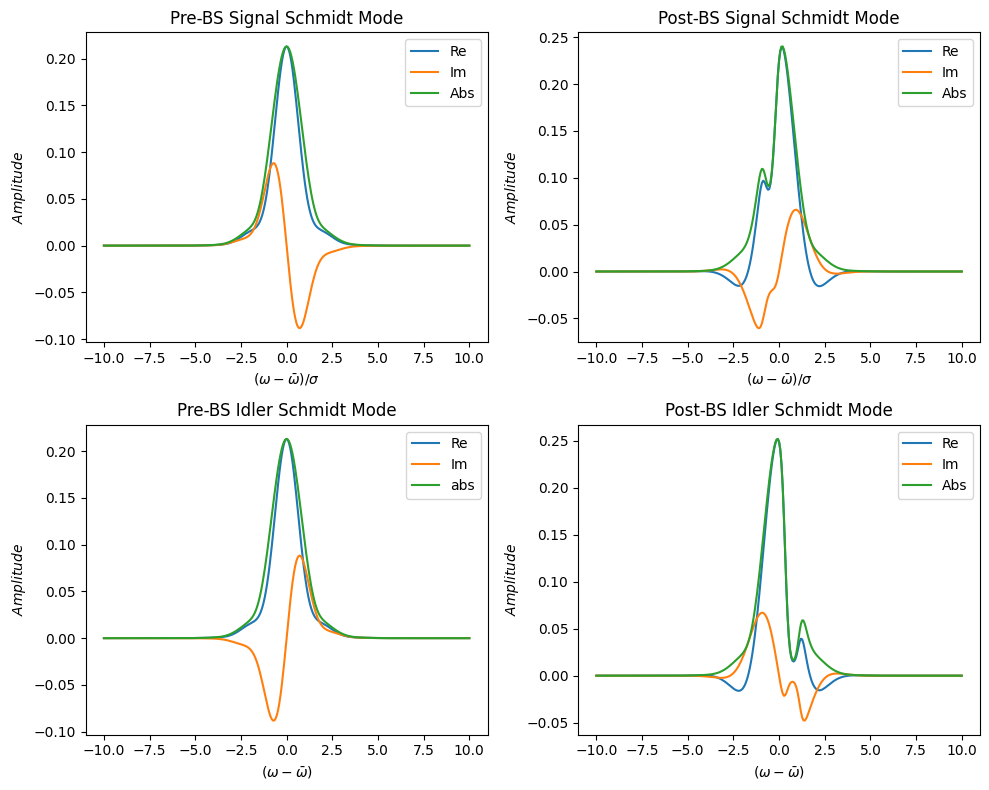

In [47]:
#Looking at the temporal modes via Nums matrix
mark=1 #this just takes the first eigenmode of interest. Choose a different value to look at different ones.
_val, us = np.linalg.eigh(Ns_p)
_val, us_bs = np.linalg.eigh(Ns_p_bs)
_val, ui = np.linalg.eigh(Ni_p)
_val, ui_bs = np.linalg.eigh(Ni_p_bs)

fig, axs = plt.subplots(2, 2, figsize=(10,8))

axs[0,0].plot(w, np.real(np.exp(-1j*np.angle(us[(N-1)//2,-mark]))*us[:,-mark]), label='Re')
axs[0,0].plot(w, np.imag(np.exp(-1j*np.angle(us[(N-1)//2,-mark]))*us[:,-mark]), label='Im')
axs[0,0].plot(w, np.abs(np.exp(-1j*np.angle(us[(N-1)//2,-mark]))*us[:,-mark]), label='Abs')
axs[0,0].set_xlabel(r"$(\omega-\bar{\omega})/\sigma$")
axs[0,0].set_ylabel(r"$Amplitude$")
axs[0,0].set_title('Pre-BS Signal Schmidt Mode')
axs[0,0].legend()

axs[0,1].plot(w, np.real(np.exp(-1j*np.angle(us_bs[(N-1)//2,-mark]))*us_bs[:,-mark]), label='Re') 
axs[0,1].plot(w, np.imag(np.exp(-1j*np.angle(us_bs[(N-1)//2,-mark]))*us_bs[:,-mark]), label='Im')
axs[0,1].plot(w, np.abs(np.exp(-1j*np.angle(us_bs[(N-1)//2,-mark]))*us_bs[:,-mark]), label='Abs')
axs[0,1].set_xlabel(r"$(\omega-\bar{\omega})/\sigma$")
axs[0,1].set_ylabel(r"$Amplitude$")
axs[0,1].set_title('Post-BS Signal Schmidt Mode')
axs[0,1].legend()

axs[1,0].plot(w, np.real(np.exp(-1j*np.angle(ui[(N-1)//2,-mark]))*ui[:,-mark]), label='Re') 
axs[1,0].plot(w, np.imag(np.exp(-1j*np.angle(ui[(N-1)//2,-mark]))*ui[:,-mark]), label='Im')
axs[1,0].plot(w, np.abs(np.exp(-1j*np.angle(ui[(N-1)//2,-mark]))*ui[:,-mark]), label='abs')
axs[1,0].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[1,0].set_ylabel(r"$Amplitude$")
axs[1,0].set_title('Pre-BS Idler Schmidt Mode')
axs[1,0].legend()

axs[1,1].plot(w, np.real(np.exp(-1j*np.angle(ui_bs[(N-1)//2,-mark]))*ui_bs[:,-mark]), label='Re') 
axs[1,1].plot(w, np.imag(np.exp(-1j*np.angle(ui_bs[(N-1)//2,-mark]))*ui_bs[:,-mark]), label='Im')
axs[1,1].plot(w, np.abs(np.exp(-1j*np.angle(ui_bs[(N-1)//2,-mark]))*ui_bs[:,-mark]), label='Abs')
axs[1,1].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[1,1].set_ylabel(r"$Amplitude$")
axs[1,1].set_title('Post-BS Idler Schmidt Mode')
axs[1,1].legend()




fig.tight_layout()
plt.show()

Pre and Post beamsplitter (BS) interaction second order moments for the **CW** case.

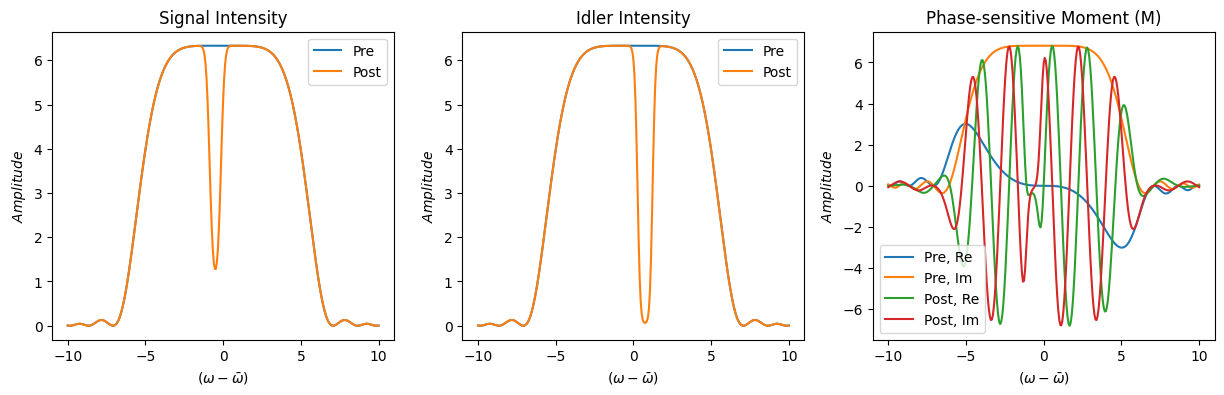

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].plot(w, np.diag(Ns_cw).real, label='Pre')
axs[0].plot(w, np.diag(Ns_cw_bs).real, label='Post')
axs[0].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[0].set_ylabel(r"$Amplitude$")
axs[0].set_title('Signal Intensity')
axs[0].legend()

axs[1].plot(w, np.diag(Ni_cw).real, label='Pre')
axs[1].plot(w, np.diag(Ni_cw_bs).real, label='Post')
axs[1].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[1].set_ylabel(r"$Amplitude$")
axs[1].set_title('Idler Intensity')
axs[1].legend()

axs[2].plot(w, np.diag(np.fliplr(M_cw)).real, label='Pre, Re')
axs[2].plot(w, np.diag(np.fliplr(M_cw)).imag, label='Pre, Im')
axs[2].plot(w, np.diag(np.fliplr(M_cw_bs)).real, label='Post, Re')
axs[2].plot(w, np.diag(np.fliplr(M_cw_bs)).imag, label='Post, Im')
axs[2].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[2].set_ylabel(r"$Amplitude$")
axs[2].set_title('Phase-sensitive Moment (M)')
axs[2].legend()

plt.show()

## SPDC update rule

This function modifies the second order moments after passing through a lossless nonlinear spdc interaction. In this example we only consider acting with identical nonlinear regions in a row (no interaction in between regions). In this case, the second order moments after the update rule should correspond to those of a single region with twice the length (when we do not remove additional phases).

In [50]:
#Moments for single region of double length.
_T, _J, _Ns, _K, M_p_2l, Ns_p_2l, Ni_p_2l = SPulsed_lin(vs, vi, vp, pump_Np, domain, l, 2*l, w, rmv = False)
_T, _J, M_cw_2l, Ns_cw_2l, Ni_cw_2l = Scw(ks, ki, gamma, 2*l)


#Using Update rule, free-propagating phases not removed in T_p
Ns_p_nl, Ni_p_nl, M_p_nl = Update_spdc(T_p, Ns_p, Ni_p, M_p)
Ns_cw_nl, Ni_cw_nl, M_cw_nl = Update_spdc(T_cw, Ns_cw, Ni_cw, M_cw)

#Converting CW moments to vectors and normalizing
Ns_cw = np.diag(np.real(Ns_cw)/np.amax(Ns_cw.real))
Ni_cw = np.diag(np.real(Ni_cw)/np.amax(Ni_cw.real)) 
M_cw = np.diag(np.fliplr(M_cw)/np.amax(M_cw.real))  

Ns_cw_2l = np.diag(np.real(Ns_cw_2l)/np.amax(Ns_cw_2l.real))
Ni_cw_2l = np.diag(np.real(Ni_cw_2l)/np.amax(Ni_cw_2l.real)) 
M_cw_2l = np.diag(np.fliplr(M_cw_2l)/np.amax(M_cw_2l.real))   

Ns_cw_nl = np.diag(np.real(Ns_cw_nl)/np.amax(Ns_cw_nl.real))
Ni_cw_nl = np.diag(np.real(Ni_cw_nl)/np.amax(Ni_cw_nl.real)) 
M_cw_nl = np.diag(np.fliplr(M_cw_nl)/np.amax(M_cw_nl.real))   

Pre- and Post-SPDC interaction first signal and idler Schmidt modes for **pulsed** case. Note that we multiply by a phase factor such that the imaginary part is 0 at the origin. We also include the first signal and idler Schmidt modes for a nonlinear region of length 2L.

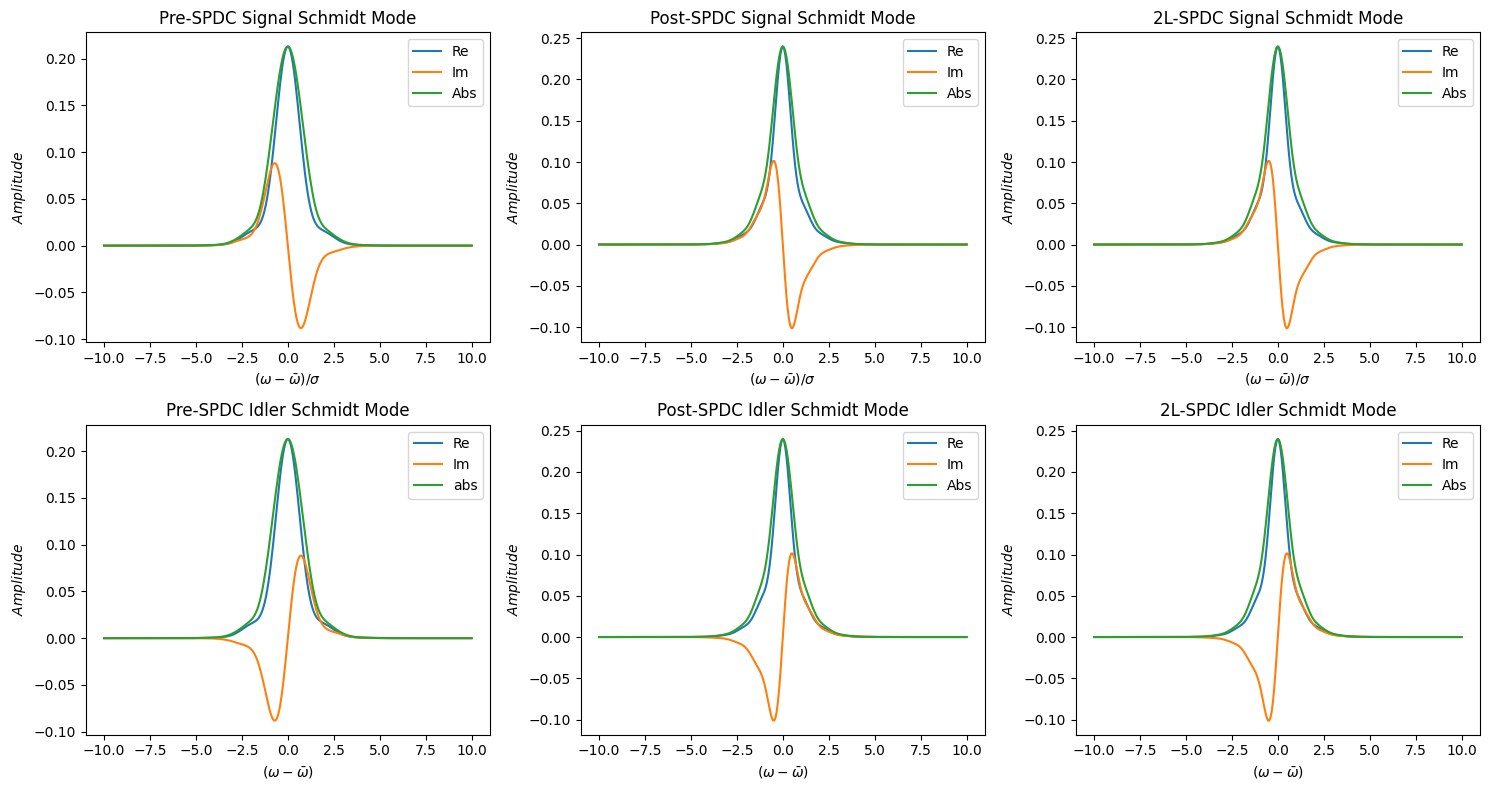

Are the second order moments for a nonlinear region of length 2L and those after the nonlinear update rule equivalent? (Nums, Numi, M): (True, True, True)


In [51]:
#Looking at the temporal modes via Nums matrix
mark=1 #this just takes the first eigenmode of interest. Choose a different value to look at different ones.
_val, us = np.linalg.eigh(Ns_p)
_val, us_nl = np.linalg.eigh(Ns_p_nl)
_val, us_2l = np.linalg.eigh(Ns_p_2l)
_val, ui = np.linalg.eigh(Ni_p)
_val, ui_nl = np.linalg.eigh(Ni_p_nl)
_val, ui_2l = np.linalg.eigh(Ni_p_2l)


fig, axs = plt.subplots(2, 3, figsize=(15,8))

axs[0,0].plot(w, np.real(np.exp(-1j*np.angle(us[(N-1)//2,-mark]))*us[:,-mark]), label='Re')
axs[0,0].plot(w, np.imag(np.exp(-1j*np.angle(us[(N-1)//2,-mark]))*us[:,-mark]), label='Im')
axs[0,0].plot(w, np.abs(np.exp(-1j*np.angle(us[(N-1)//2,-mark]))*us[:,-mark]), label='Abs')
axs[0,0].set_xlabel(r"$(\omega-\bar{\omega})/\sigma$")
axs[0,0].set_ylabel(r"$Amplitude$")
axs[0,0].set_title('Pre-SPDC Signal Schmidt Mode')
axs[0,0].legend()

axs[0,1].plot(w, np.real(np.exp(-1j*np.angle(us_nl[(N-1)//2,-mark]))*us_nl[:,-mark]), label='Re') 
axs[0,1].plot(w, np.imag(np.exp(-1j*np.angle(us_nl[(N-1)//2,-mark]))*us_nl[:,-mark]), label='Im')
axs[0,1].plot(w, np.abs(np.exp(-1j*np.angle(us_nl[(N-1)//2,-mark]))*us_nl[:,-mark]), label='Abs')
axs[0,1].set_xlabel(r"$(\omega-\bar{\omega})/\sigma$")
axs[0,1].set_ylabel(r"$Amplitude$")
axs[0,1].set_title('Post-SPDC Signal Schmidt Mode')
axs[0,1].legend()

axs[0,2].plot(w, np.real(np.exp(-1j*np.angle(us_2l[(N-1)//2,-mark]))*us_2l[:,-mark]), label='Re') 
axs[0,2].plot(w, np.imag(np.exp(-1j*np.angle(us_2l[(N-1)//2,-mark]))*us_2l[:,-mark]), label='Im')
axs[0,2].plot(w, np.abs(np.exp(-1j*np.angle(us_2l[(N-1)//2,-mark]))*us_2l[:,-mark]), label='Abs')
axs[0,2].set_xlabel(r"$(\omega-\bar{\omega})/\sigma$")
axs[0,2].set_ylabel(r"$Amplitude$")
axs[0,2].set_title('2L-SPDC Signal Schmidt Mode')
axs[0,2].legend()

axs[1,0].plot(w, np.real(np.exp(-1j*np.angle(ui[(N-1)//2,-mark]))*ui[:,-mark]), label='Re') 
axs[1,0].plot(w, np.imag(np.exp(-1j*np.angle(ui[(N-1)//2,-mark]))*ui[:,-mark]), label='Im')
axs[1,0].plot(w, np.abs(np.exp(-1j*np.angle(ui[(N-1)//2,-mark]))*ui[:,-mark]), label='abs')
axs[1,0].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[1,0].set_ylabel(r"$Amplitude$")
axs[1,0].set_title('Pre-SPDC Idler Schmidt Mode')
axs[1,0].legend()

axs[1,1].plot(w, np.real(np.exp(-1j*np.angle(ui_nl[(N-1)//2,-mark]))*ui_nl[:,-mark]), label='Re') 
axs[1,1].plot(w, np.imag(np.exp(-1j*np.angle(ui_nl[(N-1)//2,-mark]))*ui_nl[:,-mark]), label='Im')
axs[1,1].plot(w, np.abs(np.exp(-1j*np.angle(ui_nl[(N-1)//2,-mark]))*ui_nl[:,-mark]), label='Abs')
axs[1,1].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[1,1].set_ylabel(r"$Amplitude$")
axs[1,1].set_title('Post-SPDC Idler Schmidt Mode')
axs[1,1].legend()

axs[1,2].plot(w, np.real(np.exp(-1j*np.angle(ui_2l[(N-1)//2,-mark]))*ui_2l[:,-mark]), label='Re') 
axs[1,2].plot(w, np.imag(np.exp(-1j*np.angle(ui_2l[(N-1)//2,-mark]))*ui_2l[:,-mark]), label='Im')
axs[1,2].plot(w, np.abs(np.exp(-1j*np.angle(ui_2l[(N-1)//2,-mark]))*ui_2l[:,-mark]), label='Abs')
axs[1,2].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[1,2].set_ylabel(r"$Amplitude$")
axs[1,2].set_title('2L-SPDC Idler Schmidt Mode')
axs[1,2].legend()




fig.tight_layout()
plt.show()

print(f"Are the second order moments for a nonlinear region of length 2L and those after the nonlinear update rule equivalent? (Nums, Numi, M): {np.allclose(Ns_p_2l, Ns_p_nl), np.allclose(Ni_p_2l, Ni_p_nl), np.allclose(M_p_2l, M_p_nl)}")

Pre- and Post-SPDC interaction second order moments for the **CW** case. 

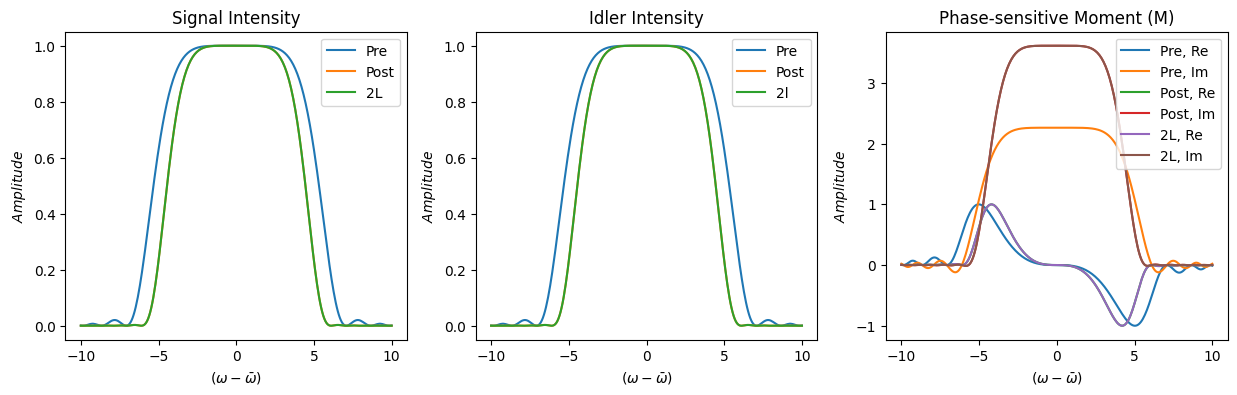

Are the second order moments for a nonlinear region of length 2L and those after the nonlinear update rule equivalent? (Nums, Numi, M): (True, True, True)


In [55]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].plot(w, Ns_cw, label='Pre')
axs[0].plot(w, Ns_cw_nl, label='Post')
axs[0].plot(w, Ns_cw_2l, label='2L')
axs[0].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[0].set_ylabel(r"$Amplitude$")
axs[0].set_title('Signal Intensity')
axs[0].legend()

axs[1].plot(w, Ni_cw, label='Pre')
axs[1].plot(w, Ni_cw_nl, label='Post')
axs[1].plot(w, Ni_cw_nl, label='2l')
axs[1].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[1].set_ylabel(r"$Amplitude$")
axs[1].set_title('Idler Intensity')
axs[1].legend()

axs[2].plot(w, M_cw.real, label='Pre, Re')
axs[2].plot(w, M_cw.imag, label='Pre, Im')
axs[2].plot(w, M_cw_nl.real, label='Post, Re')
axs[2].plot(w, M_cw_nl.imag, label='Post, Im')
axs[2].plot(w, M_cw_2l.real, label='2L, Re')
axs[2].plot(w, M_cw_2l.imag, label='2L, Im')
axs[2].set_xlabel(r"$(\omega-\bar{\omega})$")
axs[2].set_ylabel(r"$Amplitude$")
axs[2].set_title('Phase-sensitive Moment (M)')
axs[2].legend()

plt.show()

print(f"Are the second order moments for a nonlinear region of length 2L and those after the nonlinear update rule equivalent? (Nums, Numi, M): {np.allclose(Ns_cw_2l, Ns_cw_nl), np.allclose(Ni_cw_2l, Ni_cw_nl), np.allclose(M_cw_2l, M_cw_nl)}")